In [78]:
import json
import re
from statistics import mean
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pyvis.network import Network
import IPython.display as display
import plotly.graph_objects as go
import seaborn as sns

In [79]:
from utils.graph_comparison import compare_graph_datasets, GraphDatasetComparison

# I. Random Accuracy Study

## 1. MetaQA

In [80]:
metaqa = json.load(open("data/metaqa/baseline/standard/test.json", "r"))
res_metaqa = json.load(open("data/results/metaqa/eval_metaqa.json", "r"))["samples"]

In [81]:
acc = sum([1 for sample in res_metaqa if sample["gold"] == sample["pred"]]) / len(metaqa)
print("Test Accuracy: " + str(round(acc*100, 2)) + "%")

Test Accuracy: 10.05%


In [82]:
r_probs = []
for sample in metaqa:
    question = sample["question"]
    # Extract potential answers from the question (entities in triples)
    pattern = r'\(\s*([^,]+?)\s*,\s*([^,]+?)\s*,\s*([^,]+?)\s*\)'
    result = re.findall(pattern, question)
    # Filter out the header (s, p, o) and extract target entities
    potential_answers = [item[2].strip() for item in result if not (item[0].strip() == 's' and item[1].strip() == 'p')]
    unique_potential_answers = list(set(potential_answers))
    random_prob = 1/len(unique_potential_answers) if unique_potential_answers else 0
    r_probs.append(random_prob)
print("Random Chance: " + str(round(mean(r_probs)*100, 2)) + "%") if r_probs else print(0)

Random Chance: 5.51%


## 2. GSM8K 

In [83]:
with open('data/results/gsm8k/eval_samples.jsonl', 'r') as json_file:
    json_list = list(json_file)

gsm = []
for json_str in json_list:
    result = json.loads(json_str)
    gsm.append(result)
print(f"Total GSM8K samples loaded: {len(gsm)}")

Total GSM8K samples loaded: 448


In [84]:
acc = sum(sample["parsed"] == sample["ground_truth"] for sample in gsm) / len(gsm) if gsm else 0
print(f"GSM8K Accuracy: {acc*100:.2f}%")

GSM8K Accuracy: 0.89%


# II. MetaQA, KQA Pro differences and similarities with GraphQA
#### Why does HRM performs better than baseline on GraphQA and MetaQA and not on KQA Pro

## 1. MetaQA

In [85]:
metaqa = json.load(open("data/metaqa/baseline/standard/test.json", "r"))
res_metaqa = json.load(open("data/results/metaqa/eval_metaqa.json", "r"))["samples"]

In [86]:
metaqa_lengths = [len(sample["question"].split()) for sample in metaqa]
metaqa_answer_lengths = [len(sample["answer"].split()) for sample in metaqa]

df_metaqa = pd.DataFrame({
    "question_length": metaqa_lengths,
    "answer_length": metaqa_answer_lengths
})

print("MetaQA question length stats:")
print("Min:", df_metaqa["question_length"].min())
print("Max:", df_metaqa["question_length"].max())
print("Average:", df_metaqa["question_length"].mean())

print("MetaQA answer length stats:")
print("Min:", df_metaqa["answer_length"].min())
print("Max:", df_metaqa["answer_length"].max())
print("Average:", df_metaqa["answer_length"].mean())

MetaQA question length stats:
Min: 46
Max: 672
Average: 484.24706867671694
MetaQA answer length stats:
Min: 1
Max: 8
Average: 1.5510887772194304


In [87]:
def extract_triples(question, pattern=None):
    if pattern is None:
        pattern = r'\(\s*([^()]+?)\s*,\s+([^()]+?)\s*,\s+([^()]+?)\s*\)'
    return re.findall(pattern, question)

def make_graph(triples):
    G = nx.DiGraph()
    for source, relation, target in triples:
        G.add_edge(source.strip(), target.strip(), label=relation.strip())
    return G

question = metaqa[0]["question"]
answer = metaqa[0]["answer"]

pattern = r'\(\s*([^()]+?)\s*,\s+([^()]+?)\s*,\s+([^()]+?)\s*\)'
triples = extract_triples(question, pattern)

G = make_graph(triples)

In [88]:
print(question)
print(answer)

In a knowledge graph, (s, p, o) means that entity s is linked to entity o by relation p.
The facts are:
(Zindagi Na Milegi Dobara, starred actors, Kalki Koechlin)
(Evil, written by, Mikael Håfström)
(Saawariya, starred actors, Salman Khan)
(The Strange Case of Angelica, directed by, Manoel de Oliveira)
(Blood for Dracula, directed by, Paul Morrissey)
(Tatie Danielle, directed by, Étienne Chatiliez)
(Tere Naam, starred actors, Salman Khan)
(Shanghai, directed by, Mikael Håfström)
(Insidious, directed by, James Wan)
(Road, Movie, release year, 2009)
(Tere Naam, written by, Bala)
(The Sure Thing, starred actors, John Cusack)
(Shanghai, release year, 2012)
(Tere Naam, directed by, Satish Kaushik)
(The Journey of Natty Gann, starred actors, John Cusack)
(Shanghai, written by, Dibakar Banerjee)
(Poltergeist III, directed by, Gary Sherman)
(The Crusades, directed by, Cecil B. DeMille)
(Must Love Dogs, starred actors, John Cusack)
(Breakfast of Champions, directed by, Alan Rudolph)
(The Number

In [89]:
# Initialize PyVis Network
net = Network(height="600px", width="100%", directed=True)

# Load your existing NetworkX graph G
net.from_nx(G)

# # Enable interactive physics GUI controls (optional)
# net.show_buttons(filter_=['physics'])

# # Save and open in your browser
# net.write_html("interactive_graph.html")

In [90]:
def plot_graph(G, answer):
    # 1. Calculate positions for the NetworkX graph
    pos = nx.spring_layout(G, seed=42)

    # 2. Extract edge positions
    edge_x = []
    edge_y = []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=1, color="#888"),
        hoverinfo="none",
        mode="lines",
    )

    # 3. Extract node positions and names
    node_x = []
    node_y = []
    node_text = []
    node_colors = []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)

        node_color = "Green" if answer.split('.')[0] in node else "SkyBlue"
        node_colors.append(node_color)
        node_y.append(y)
        node_text.append(str(node))

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=node_text,
        textposition="top center",
        hoverinfo="text",
        marker=dict(size=20, color=node_colors, line_width=2),
    )

    # 4. Create interactive Plotly figure (pan, zoom, hover)
    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            showlegend=False,
            hovermode="closest",
            margin=dict(b=0, l=0, r=0, t=0),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        ),
    )

    fig.show()

plot_graph(G, answer)

## 2. KQA Pro 

In [91]:
kqa = json.load(open("data/kqapro/baseline/standard/test.json", "r"))

In [92]:
kqa_lengths = [len(sample["question"].split()) for sample in kqa]
kqa_answer_lengths = [len(sample["answer"].split()) for sample in kqa]

df_kqa = pd.DataFrame({
    "question_length": kqa_lengths,
    "answer_length": kqa_answer_lengths
})

print("KQA question length stats:")
print("Min:", df_kqa["question_length"].min())
print("Max:", df_kqa["question_length"].max())
print("Average:", df_kqa["question_length"].mean())

print("KQA answer length stats:")
print("Min:", df_kqa["answer_length"].min())
print("Max:", df_kqa["answer_length"].max())
print("Average:", df_kqa["answer_length"].mean())

KQA question length stats:
Min: 52
Max: 1528
Average: 553.7954144620811
KQA answer length stats:
Min: 1
Max: 10
Average: 1.6657848324514992


In [93]:
kqa_question = kqa[0]["question"]
kqa_answer = kqa[0]["answer"]
kqa_triples = extract_triples(kqa_question, pattern)
kqa_G = make_graph(kqa_triples)
plot_graph(kqa_G, kqa_answer)

## 3. GraphQA

In [94]:
graphqa = json.load(open("data/graphqa/baseline/standard/test.json"))

graphqa_lengths = [len(sample["question"]) for sample in graphqa]
graphqa_answer_lengths = [len(sample["answer"]) for sample in graphqa]

df_graphqa = pd.DataFrame({
    "question_length": graphqa_lengths,
    "answer_length": graphqa_answer_lengths
})

print("GraphQA question length stats:")
print("Min:", df_graphqa["question_length"].min())
print("Max:", df_graphqa["question_length"].max())
print("Average:", df_graphqa["question_length"].mean())

print("GraphQA answer length stats:")
print("Min:", df_graphqa["answer_length"].min())
print("Max:", df_graphqa["answer_length"].max())
print("Average:", df_graphqa["answer_length"].mean())

GraphQA question length stats:
Min: 223
Max: 1650
Average: 472.1974025974026
GraphQA answer length stats:
Min: 2
Max: 54
Average: 7.301298701298701


In [95]:
question

"In a knowledge graph, (s, p, o) means that entity s is linked to entity o by relation p.\nThe facts are:\n(Zindagi Na Milegi Dobara, starred actors, Kalki Koechlin)\n(Evil, written by, Mikael Håfström)\n(Saawariya, starred actors, Salman Khan)\n(The Strange Case of Angelica, directed by, Manoel de Oliveira)\n(Blood for Dracula, directed by, Paul Morrissey)\n(Tatie Danielle, directed by, Étienne Chatiliez)\n(Tere Naam, starred actors, Salman Khan)\n(Shanghai, directed by, Mikael Håfström)\n(Insidious, directed by, James Wan)\n(Road, Movie, release year, 2009)\n(Tere Naam, written by, Bala)\n(The Sure Thing, starred actors, John Cusack)\n(Shanghai, release year, 2012)\n(Tere Naam, directed by, Satish Kaushik)\n(The Journey of Natty Gann, starred actors, John Cusack)\n(Shanghai, written by, Dibakar Banerjee)\n(Poltergeist III, directed by, Gary Sherman)\n(The Crusades, directed by, Cecil B. DeMille)\n(Must Love Dogs, starred actors, John Cusack)\n(Breakfast of Champions, directed by, Ala

In [96]:
graphqa_question = graphqa[0]["question"]
graphqa_answer = graphqa[0]["answer"]

graphqa_pattern = r'\(\s*(\d+)\s*,\s*(\d+)\s*\)'

def make_graph_from_couples(couples):
    G = nx.Graph()
    for u, v in couples:
        G.add_edge(u, v)
    return G

graphqa_couples = extract_triples(graphqa_question, graphqa_pattern)
graphqa_G = make_graph_from_couples(graphqa_couples)
plot_graph(graphqa_G, graphqa_answer)

## 4. Summary

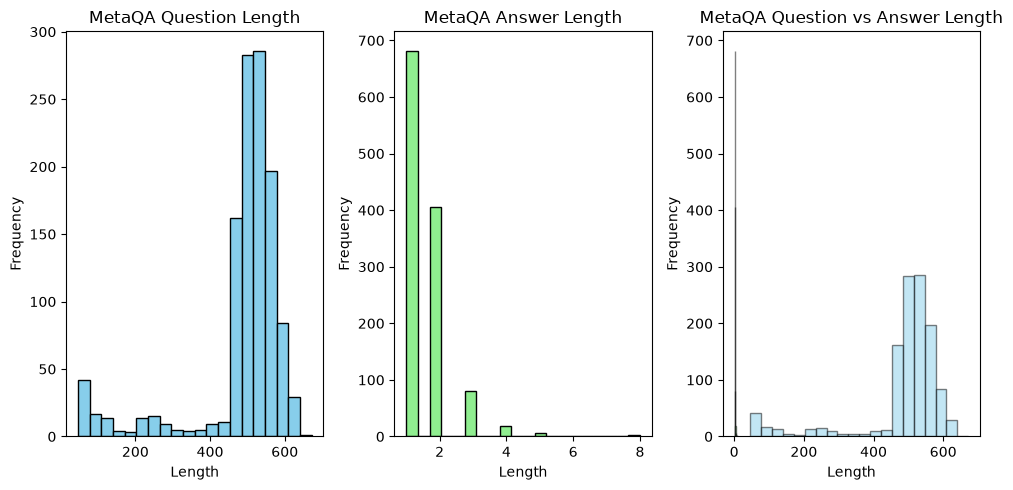

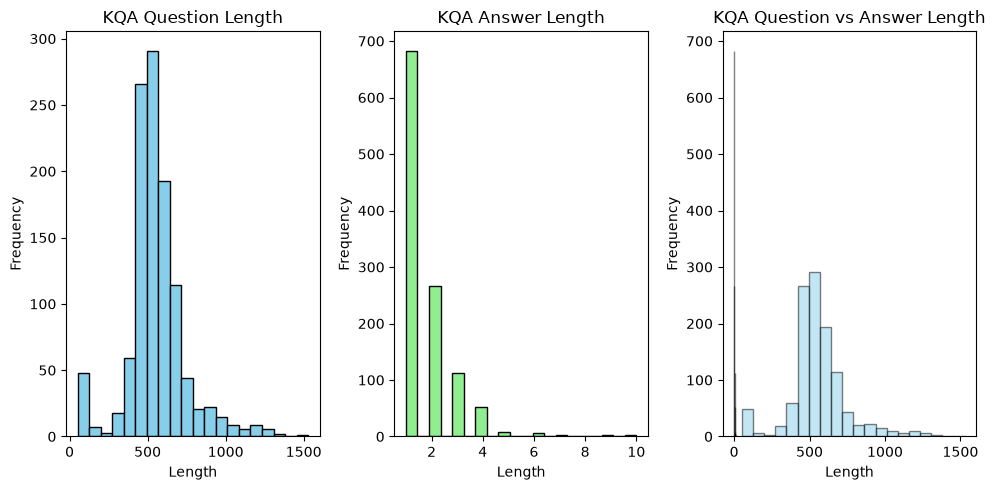

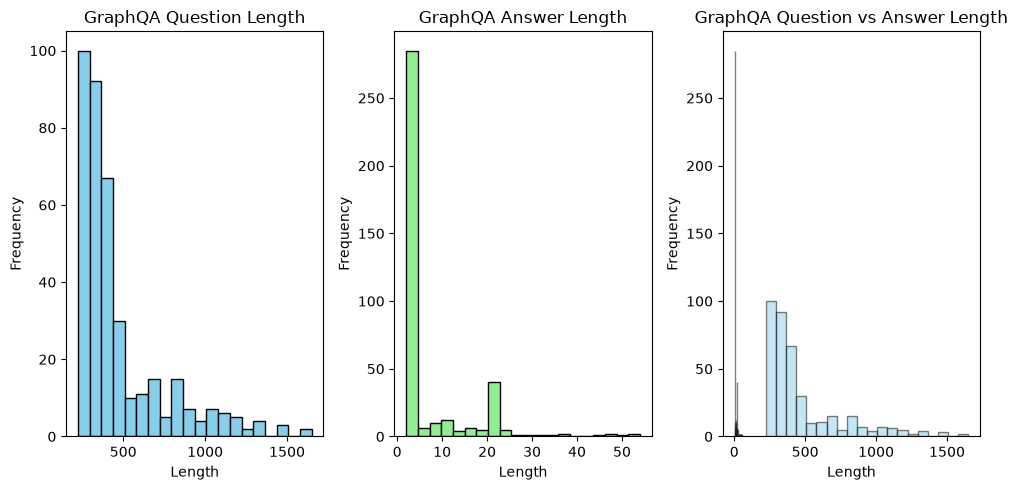

In [97]:
datasets = {
    "MetaQA": df_metaqa,
    "KQA": df_kqa,
    "GraphQA": df_graphqa
}

for dataset_name, df in datasets.items():
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.hist(df["question_length"], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"{dataset_name} Question Length")
    plt.xlabel("Length")
    plt.ylabel("Frequency")

    plt.subplot(1, 3, 2)
    plt.hist(df["answer_length"], bins=20, color='lightgreen', edgecolor='black')
    plt.title(f"{dataset_name} Answer Length")
    plt.xlabel("Length")
    plt.ylabel("Frequency")

    plt.subplot(1, 3, 3)
    plt.hist(df["question_length"], bins=20, color='skyblue', edgecolor='black', alpha=0.5)
    plt.hist(df["answer_length"], bins=20, color='lightgreen', edgecolor='black', alpha=0.5)
    plt.title(f"{dataset_name} Question vs Answer Length")
    plt.xlabel("Length")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## 5. Statistical Comparison

In [98]:
mqa_graphs = []
kqa_graphs = []
graphqa_graphs = []

for sample_metaqa, sample_kqa, sample_graphqa in zip(metaqa, kqa, graphqa):
    mqa_question = sample_metaqa["question"]
    mqa_answer = sample_metaqa["answer"]
    mqa_triples = extract_triples(mqa_question, pattern)
    mqa_G = make_graph(mqa_triples)
    mqa_graphs.append(mqa_G)

    kqa_question = sample_kqa["question"]
    kqa_answer = sample_kqa["answer"]
    kqa_triples = extract_triples(kqa_question, pattern)
    kqa_G = make_graph(kqa_triples)
    kqa_graphs.append(kqa_G)

    graphqa_question = sample_graphqa["question"]
    graphqa_answer = sample_graphqa["answer"]
    graphqa_couples = extract_triples(graphqa_question, graphqa_pattern)
    graphqa_G = make_graph_from_couples(graphqa_couples)
    graphqa_graphs.append(graphqa_G)


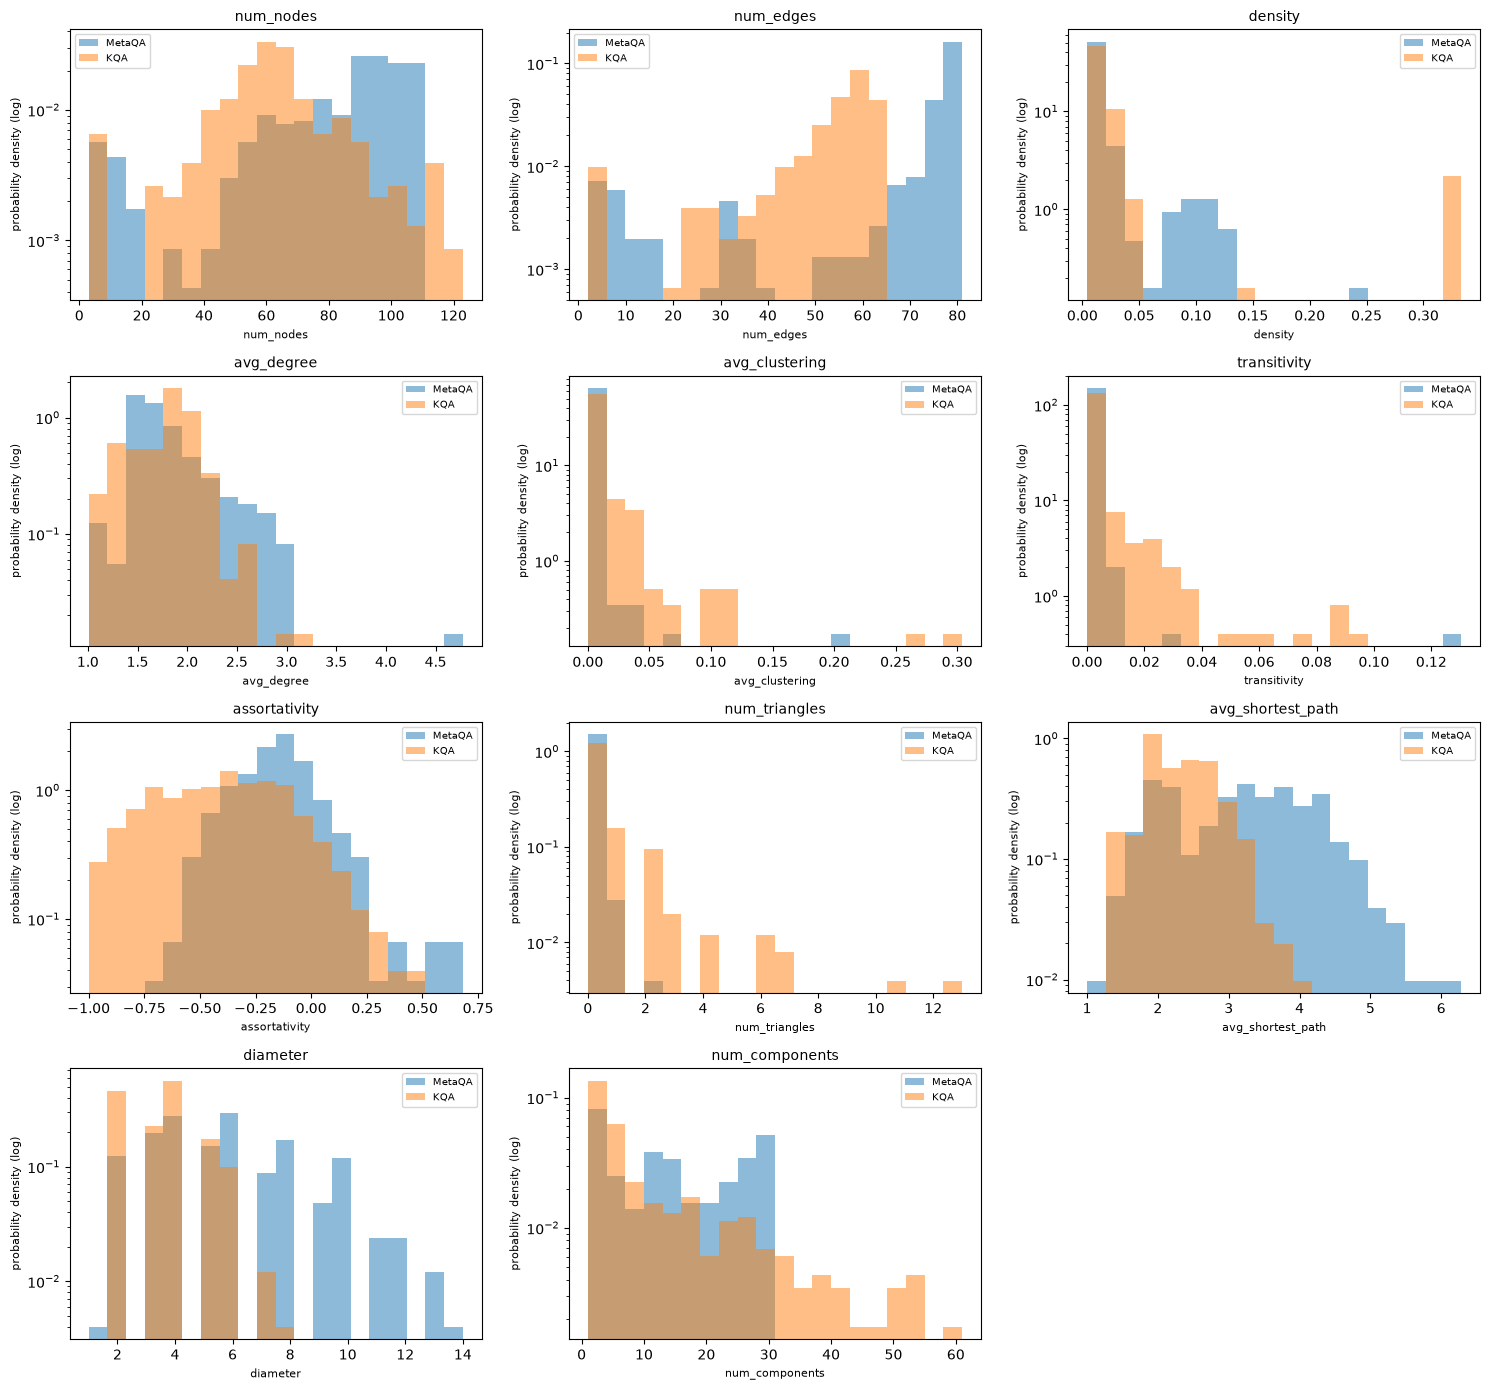

In [99]:
_ = compare_graph_datasets(mqa_graphs, kqa_graphs, label_a = "MetaQA", label_b = "KQA")

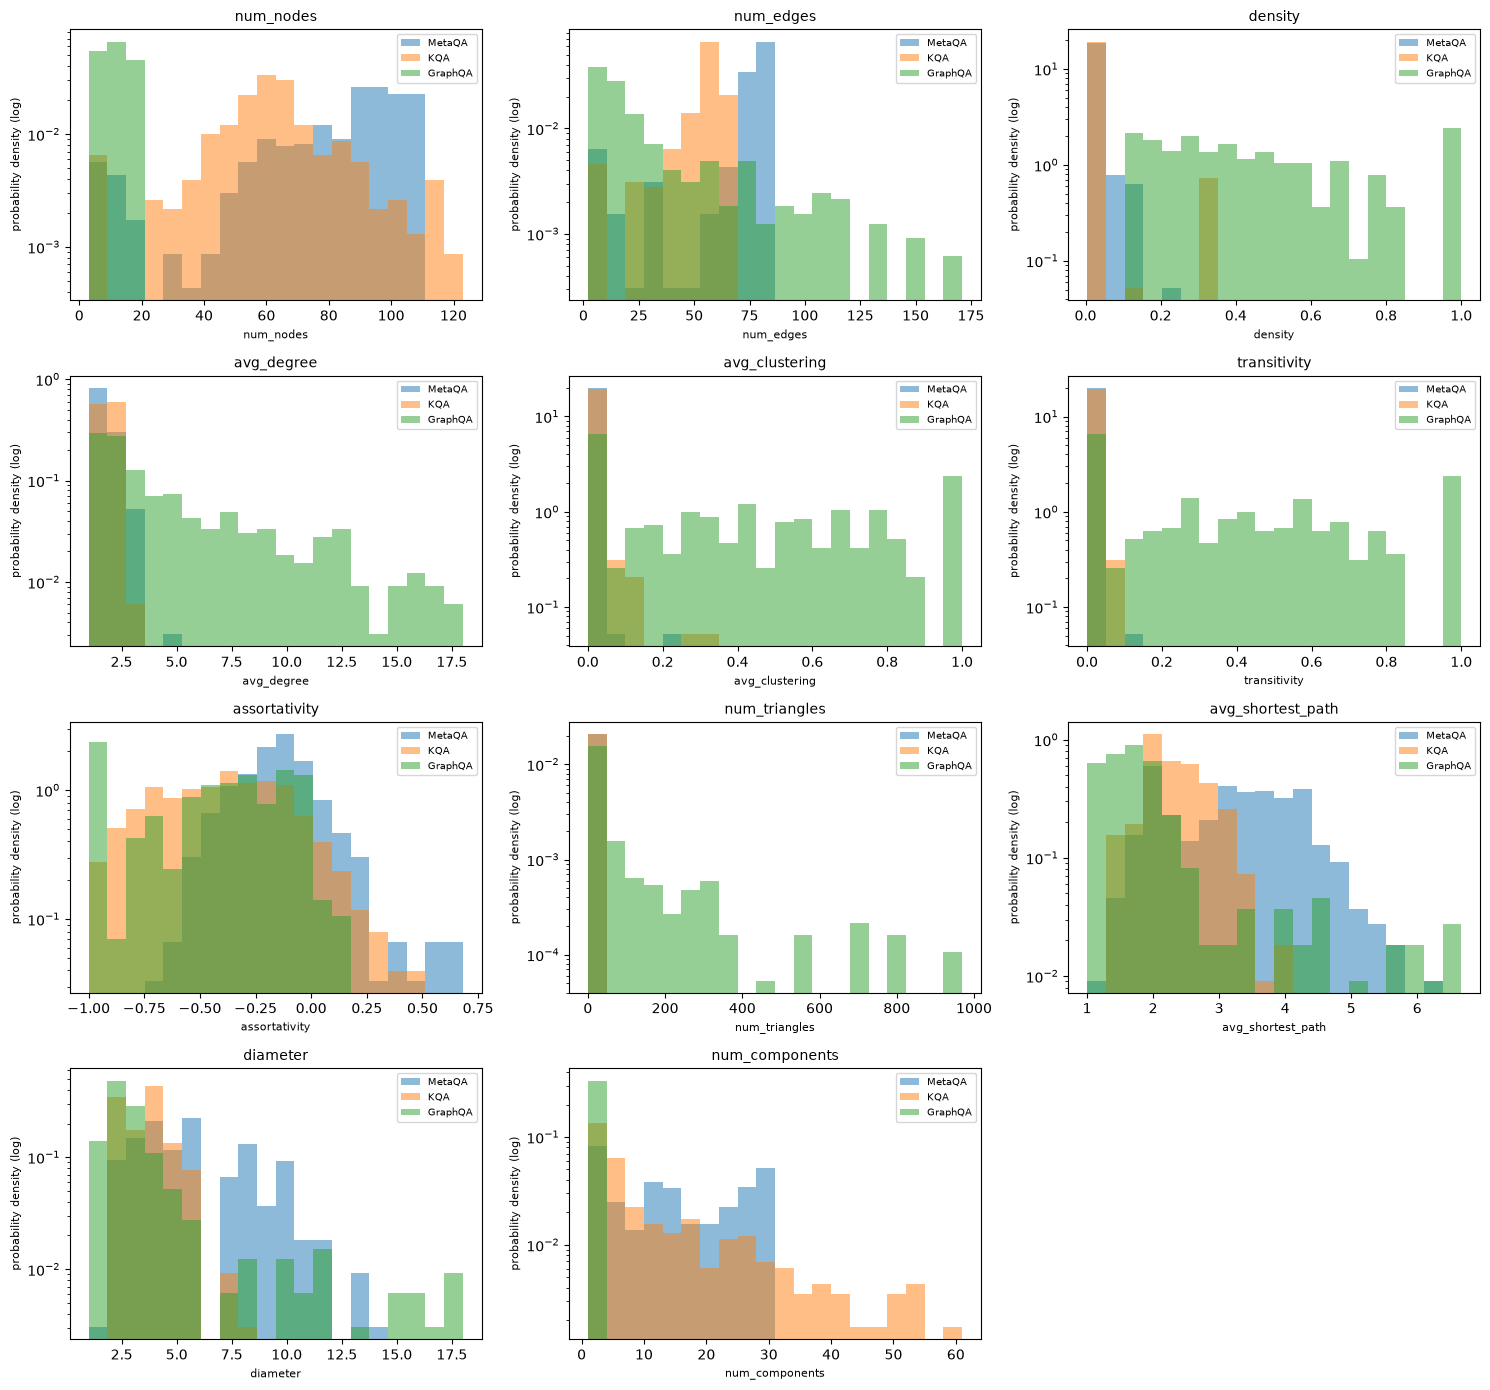

In [100]:
comp = GraphDatasetComparison(
    {
        "MetaQA": mqa_graphs,
        "KQA": kqa_graphs,
        "GraphQA": graphqa_graphs,
    }
    
)

results = comp.compare(run_mmd=True)

In [101]:
results["mmd_matrix"]

,MetaQA,KQA,GraphQA
MetaQA,0.000000,0.087319,0.317424
KQA,0.087319,0.000000,0.474328
GraphQA,0.317424,0.474328,0.000000


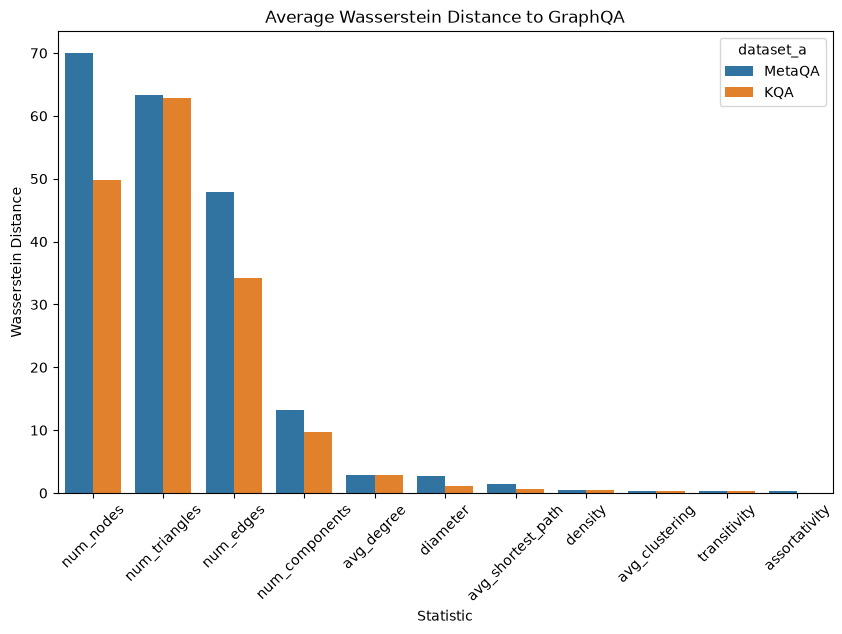

In [102]:
df_filtered = results["pairwise_tests"][
    (results["pairwise_tests"]["dataset_b"] == "GraphQA") & 
    (results["pairwise_tests"]["dataset_a"].isin(["MetaQA", "KQA"]))
]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_filtered, 
    x="statistic", 
    y="wasserstein_distance", 
    hue="dataset_a"
)

plt.xlabel("Statistic")
plt.ylabel("Wasserstein Distance")
plt.title("Average Wasserstein Distance to GraphQA")
plt.xticks(rotation=45)
plt.show()

## 6. Graph Path and Question/Answer Study

How does question and answer connect in MetaQA (not sure the same is possible for KQA Pro)

In [103]:
paths = [
    "data/metaqa/1-hop/vanilla/qa_dev.txt",
    "data/metaqa/2-hop/vanilla/qa_dev.txt",
    "data/metaqa/3-hop/vanilla/qa_dev.txt",
    "data/metaqa/1-hop/vanilla/qa_test.txt",
    "data/metaqa/2-hop/vanilla/qa_test.txt",
    "data/metaqa/3-hop/vanilla/qa_test.txt",
    "data/metaqa/1-hop/vanilla/qa_train.txt",
    "data/metaqa/2-hop/vanilla/qa_train.txt",
    "data/metaqa/3-hop/vanilla/qa_train.txt",
]
original_metaqa = []
for path in paths:
    with open(path, "r") as f:
        data = f.read().splitlines()
    original_metaqa.extend(data)



In [104]:
clean_omqa = []
for item in original_metaqa:
    clean_omqa.append({"question": item.split('\t')[0], 
                       "answers": item.split('\t')[1].split("|")})

clean_omqa[0]

{'question': 'what movies did [Temuera Morrison] act in',
 'answers': ['Once Were Warriors', 'Tracker', 'River Queen']}

In [105]:
mqa_question = metaqa[3]["question"].split("Q:")[1].split("\n")[0].strip()
mqa_answer = metaqa[3]["answer"]
mqa_question, mqa_answer

('who is listed as director for Poltergeist', 'Tobe Hooper.')

In [106]:
for item in clean_omqa:
    if mqa_question in item["question"].replace("[", "").replace("]", ""):
        print(item)
        q_entity = re.findall(r'\[(.*?)\]', item["question"])[0]
        a_entity = item["answers"][0]
q_entity, a_entity

{'question': 'who is listed as director for [Poltergeist]', 'answers': ['Tobe Hooper']}


('Poltergeist', 'Tobe Hooper')

In [107]:
def plot_graph2(G, question, answer):
    # 1. Calculate positions for the NetworkX graph
    pos = nx.spring_layout(G, seed=42)

    # Extract question and answer entities
    q_entity = question.split('.')[0]
    a_entity = answer.split('.')[0]
    
    # Find shortest path between question and answer entities
    shortest_path = None
    try:
        shortest_path = nx.shortest_path(G, source=q_entity, target=a_entity)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        shortest_path = None
    
    # Create set of edges in the shortest path for quick lookup
    path_edges = set()
    if shortest_path:
        for i in range(len(shortest_path) - 1):
            edge = (shortest_path[i], shortest_path[i + 1])
            reverse_edge = (shortest_path[i + 1], shortest_path[i])
            path_edges.add(edge)
            path_edges.add(reverse_edge)

    # 2. Extract regular edge positions (non-path edges)
    edge_x = []
    edge_y = []
    for edge in G.edges():
        if edge not in path_edges and (edge[1], edge[0]) not in path_edges:
            x0, y0 = pos[edge[0]]
            x1, y1 = pos[edge[1]]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=1, color="#888"),
        hoverinfo="none",
        mode="lines",
    )
    
    # 2b. Extract path edge positions (shortest path edges in deeper blue)
    path_edge_x = []
    path_edge_y = []
    if shortest_path:
        for i in range(len(shortest_path) - 1):
            node1 = shortest_path[i]
            node2 = shortest_path[i + 1]
            x0, y0 = pos[node1]
            x1, y1 = pos[node2]
            path_edge_x.extend([x0, x1, None])
            path_edge_y.extend([y0, y1, None])
    
    path_edge_trace = go.Scatter(
        x=path_edge_x,
        y=path_edge_y,
        line=dict(width=3, color="#00008B"),  # Dark blue for shortest path
        hoverinfo="none",
        mode="lines",
    )

    # 3. Extract node positions and names
    node_x = []
    node_y = []
    node_text = []
    node_colors = []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_color = "Green" if a_entity in node else "SkyBlue"
        if node_color == "Green":
            node_color = "Green"
        node_color = "Red" if q_entity in node else node_color
        node_colors.append(node_color)
        node_y.append(y)
        node_text.append(str(node))

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=node_text,
        textposition="top center",
        hoverinfo="text",
        marker=dict(size=20, color=node_colors, line_width=2),
    )

    # 4. Create interactive Plotly figure (pan, zoom, hover)
    fig = go.Figure(
        data=[edge_trace, path_edge_trace, node_trace],
        layout=go.Layout(
            showlegend=False,
            hovermode="closest",
            margin=dict(b=0, l=0, r=0, t=0),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        ),
    )

    fig.show()

In [108]:
triples = extract_triples(metaqa[3]["question"], pattern)
G = make_graph(triples)
plot_graph2(G, q_entity, a_entity)